# Workstream 2: Competitive landscape
**Client question:** who will the client's pill compete with when it launches (~2028), and is its edge (a novel, non-serotonin, well-tolerated second-line pill) still distinctive by then?

| Sub-question | Source |
|---|---|
| 1. Which drugs are in late-stage trials for depression, from whom, and by when could they launch? | ClinicalTrials.gov API (Phase 2/3, 2015+) |
| 2. How many use a non-serotonin mechanism, i.e. compete head-on with the client's edge? | ClinicalTrials.gov + mechanism mapping (company and FDA sources) |
| 3. What non-drug alternatives compete for the same second-line patients (TMS, digital therapeutics, psychedelic-assisted therapy, psychotherapy)? | ClinicalTrials.gov intervention types + desk research |
| 4. So what: which competitors arrive before or after the client, and how should that shape positioning? | Synthesis |

In [1]:
import sys
import pandas as pd
import matplotlib.pyplot as plt

RAW, OUT, FIG = "../data/raw/", "../data/processed/", "../outputs/"
pd.set_option("display.max_colwidth", 80)

CLIENT_LAUNCH_YEAR = 2028     # Phase 3 data in 2027, launch assumed ~2028

## Step 1: What is in the ClinicalTrials.gov download?
`scripts/01_download_data.py trials` saved every **interventional** study on depression that started in **2015 or later**, all phases and all intervention types (drugs, devices, behavioral, digital).
- `phases`: EARLY_PHASE1, PHASE1, PHASE2, PHASE3, PHASE4 or NA (devices and behavioral studies usually have no phase); a study can list two (e.g. PHASE2|PHASE3).
- `sponsor_class`: INDUSTRY, NIH, OTHER (universities, hospitals) and so on.
- `intervention_types`: DRUG, DEVICE, BEHAVIORAL, BIOLOGICAL, PROCEDURE, OTHER, ...

In [2]:
trials = pd.read_csv(RAW + "ctgov_depression_trials.csv", dtype=str)
trials["start_year"] = pd.to_numeric(trials.start_date.str[:4], errors="coerce")
trials["enrollment"] = pd.to_numeric(trials.enrollment, errors="coerce")

# Data profile: check what is in the file before drawing any conclusion
print(f"Trials: {len(trials):,} | unique NCT ids: {trials.nct_id.nunique():,} | start years {trials.start_year.min():.0f}-{trials.start_year.max():.0f}")
for col in ["status", "phases", "sponsor_class", "intervention_types"]:
    print(f"\n{col}:"); print(trials[col].fillna("(blank)").value_counts().head(12).to_string())

Trials: 7,393 | unique NCT ids: 7,393 | start years 2015-2028

status:
status
COMPLETED                  3618
RECRUITING                 1210
UNKNOWN                    1091
NOT_YET_RECRUITING          536
ACTIVE_NOT_RECRUITING       302
TERMINATED                  273
WITHDRAWN                   213
ENROLLING_BY_INVITATION     113
SUSPENDED                    37

phases:
phases
(blank)          5921
PHASE2            475
PHASE4            306
PHASE3            257
PHASE1            195
PHASE1|PHASE2      87
EARLY_PHASE1       83
PHASE2|PHASE3      69

sponsor_class:
sponsor_class
OTHER        6470
INDUSTRY      605
OTHER_GOV     170
FED           112
NIH            21
NETWORK        11
INDIV           4

intervention_types:
intervention_types
BEHAVIORAL            3012
DRUG                  1096
OTHER                 1090
DEVICE                 945
BEHAVIORAL|OTHER       317
DRUG|OTHER             129
DIETARY_SUPPLEMENT     123
BEHAVIORAL|DEVICE       89
BEHAVIORAL|DRUG         86
PRO

## Step 2: Late-stage drug pipeline
**2a. Funnel.** Narrow every depression trial down to the drug candidates that could realistically compete with the client around 2028. Each stage removes trials that cannot become a competing product in time:
1. **All trials**: everything in the download.
2. **Testing a drug**: devices and therapy are handled separately in Step 3.
3. **Company-sponsored**: universities and hospitals study treatments but rarely launch products; companies do.
4. **Phase 2 or 3**: a new drug takes roughly 5-8 years from Phase 1 to approval; only Phase 2/3 candidates can plausibly reach the market by ~2028-2030.
5. **Major or treatment-resistant depression**: the client's patients. Removes bipolar, postpartum and other types, which are separate markets.
6. **Still running, or finished 2023+**: older finished trials either already led to an approved drug (known competitors) or to a dead end; recent results may still lead to a filing.

The filters combine (a trial must pass all of them), so the final count does not depend on their order; the order only sets how the story reads. A phase x status table at the end shows which late-stage trials are finished and which are still running.

In [3]:
# Step 2a. Funnel: from every depression trial to the late-stage drug candidates that could compete around 2028
ACTIVE = ["RECRUITING", "NOT_YET_RECRUITING", "ACTIVE_NOT_RECRUITING", "ENROLLING_BY_INVITATION"]
has = lambda col, pattern: trials[col].fillna("").str.contains(pattern, case=False, regex=True)

# Condition filter: major / treatment-resistant depression, or plain "depression" that is not another type
MDD = r"major depress|treatment[- ]resistant|\bmdd\b|\btrd\b|depressive disorder, major|unipolar"
OTHER_DEPRESSION = r"bipolar|postpartum|post-partum|post partum|postnatal|respiratory|parkinson|premenstrual|alzheimer"
is_mdd = has("conditions", MDD) | (has("conditions", "depress") & ~has("conditions", OTHER_DEPRESSION))

# 'Still relevant' = still running, or finished recently (primary completion 2023+), so results or a filing may still be coming
recent = trials.status.isin(ACTIVE) | ((trials.status == "COMPLETED") & (trials.primary_completion_date.fillna("").str[:4] >= "2023"))

stages = {
    "1. All depression trials (interventional, started 2015+)": pd.Series(True, index=trials.index),
    "2. Testing a drug (not only a device or therapy)":         has("intervention_types", "DRUG|BIOLOGICAL|COMBINATION_PRODUCT"),
    "3. Run by a company (sponsor_class = INDUSTRY)":           trials.sponsor_class == "INDUSTRY",
    "4. Phase 2 or Phase 3 (late stage)":                       has("phases", "PHASE2|PHASE3"),
    "5. Major or treatment-resistant depression":               is_mdd,
    "6. Still running, or finished 2023 or later":              recent,
}
keep = pd.Series(True, index=trials.index)
funnel = []
for name, mask in stages.items():
    keep &= mask
    funnel.append({"Stage": name, "Trials left": int(keep.sum())})
funnel = pd.DataFrame(funnel).set_index("Stage")
funnel["% of previous stage"] = (funnel["Trials left"] / funnel["Trials left"].shift(1) * 100).round(0)
display(funnel)

# Check stage 5: what kinds of depression did it remove? (should be bipolar, postpartum etc., not MDD)
before5 = stages["2. Testing a drug (not only a device or therapy)"] & stages["3. Run by a company (sponsor_class = INDUSTRY)"] & stages["4. Phase 2 or Phase 3 (late stage)"]
print("Removed at stage 5, most common conditions:")
print(trials[before5 & ~is_mdd].conditions.value_counts().head(8).to_string())

late = trials[keep].copy()
print(f"\nLate-stage, still-relevant trials: {len(late)} | status: {late.status.value_counts().to_dict()}")

# Company Phase 2/3 drug trials in MDD (stages 1-5): which phase, and are they finished or still running?
before6 = before5 & is_mdd
grid = pd.crosstab(trials[before6].phases, trials[before6].status, margins=True, margins_name="Total")
print("\nStages 1-5, phase x status (rows: phase, columns: trial status):"); display(grid)

,Trials left,% of previous stage
Stage,,
"1. All depression trials (interventional, started 2015+)",7393,NaN
2. Testing a drug (not only a device or therapy),1536,21.0
3. Run by a company (sponsor_class = INDUSTRY),413,27.0
4. Phase 2 or Phase 3 (late stage),304,74.0
5. Major or treatment-resistant depression,244,80.0
"6. Still running, or finished 2023 or later",118,48.0


Removed at stage 5, most common conditions:
conditions
Postpartum Depression                        7
Bipolar Depression                           6
Bipolar Disorder                             3
Bipolar Depression; Suicidal Ideation        3
Bipolar I Disorder; Bipolar II Disorder      2
Bipolar Disorder; Depression                 2
Premenstrual Dysphoric Disorder              2
Depressive Episodes, Bipolar I Depression    2

Late-stage, still-relevant trials: 118 | status: {'COMPLETED': 61, 'RECRUITING': 38, 'NOT_YET_RECRUITING': 11, 'ACTIVE_NOT_RECRUITING': 5, 'ENROLLING_BY_INVITATION': 3}

Stages 1-5, phase x status (rows: phase, columns: trial status):


status,ACTIVE_NOT_RECRUITING,COMPLETED,ENROLLING_BY_INVITATION,NOT_YET_RECRUITING,RECRUITING,TERMINATED,UNKNOWN,WITHDRAWN,Total
phases,,,,,,,,,
PHASE1|PHASE2,1,6,0,1,1,0,0,0,9
PHASE2,1,77,1,3,16,7,8,3,116
PHASE2|PHASE3,0,2,0,2,1,0,0,0,5
PHASE3,3,60,2,5,20,20,1,3,114
Total,5,145,3,11,38,27,9,6,244


**2b. One row per drug candidate.** Many trials test the same molecule (e.g. several Phase 3 studies of one drug), so trials are grouped by their test drug.
- The test drug is the first intervention that is not a placebo, a procedure or an older comparator drug (e.g. sertraline used as a benchmark).
- Names are cleaned (doses and tablet forms removed) and code names are mapped to drug names where they are the same molecule (e.g. XEN1101 = azetukalner).
- *furthest_phase*: most advanced phase reached; *active_trials*: trials still running; *latest_data*: latest expected primary completion, i.e. roughly when the final key results arrive.

In [4]:
# Step 2b. One row per drug candidate: many trials test the same molecule
import re

# Interventions that are not the candidate itself: placebo, comparator drugs, procedures
NOT_CANDIDATE = (r"placebo|sham|standard of care|background|psychotherapy|psychological support|midazolam|selective serotonin|"
                 r"electroencephal|biochemical|acute subject|sublingual administration|intranasal device|\btms\b|vital signs|assessment|monitor")
COMPARATORS = ["sertraline", "escitalopram", "duloxetine", "quetiapine", "vortioxetine"]   # older drugs used as a benchmark arm
ALIASES = {"xen1101": "azetukalner", "nmra-335140": "navacaprant", "sage-217": "zuranolone", "js1-1": "js1-1-01"}  # code name -> drug name, same molecule

def clean(name):
    """Lower-case a drug name and strip doses, dosage forms and salts, so 'XEN1101 10 mg' and 'XEN1101 20 mg' match."""
    n = name.lower()
    n = re.sub(r"\b\d+(\.\d+)?\s*(mg|μg|ug|mcg)\b(/day)?", " ", n)
    n = re.sub(r"\b(\d+ )?(low|median|high)[- ]dose( group)?\b|\bgroup\b|\bpart b:", " ", n)
    n = re.sub(r"\b(tablets?|capsules?|oral|po|pills?|sustained-release|extended-release|enteric-coated|hydrochloride|hydrobromide|"
               r"phosphate|subcutaneous injection|nasal spray|depot|mtd|er|of|and)\b|[()™®]", " ", n)
    n = re.sub(r"\s+", " ", n).strip(" -;,")
    return ALIASES.get(n, n)

def candidate(interventions):
    """Pick the trial's test drug: the first intervention that is not a placebo, procedure or comparator."""
    names = [n.strip() for n in str(interventions).split(";") if n.strip() and not re.search(NOT_CANDIDATE, n, re.I)]
    test = [n for n in names if not any(c in n.lower() for c in COMPARATORS)]
    return clean((test or names or [""])[0])

late["candidate"] = late.interventions.apply(candidate)
print("Trials with no identifiable test drug (dropped):", (late.candidate == "").sum())
late = late[late.candidate != ""]

PHASE_RANK = {"PHASE3": 4, "PHASE2|PHASE3": 3, "PHASE2": 2, "PHASE1|PHASE2": 1}
late["phase_rank"] = late.phases.map(PHASE_RANK).fillna(0)
late["is_active"] = late.status.isin(ACTIVE)

pipeline = (late.groupby("candidate")
            .agg(sponsor=("sponsor", lambda s: s.mode()[0]),
                 furthest_phase=("phase_rank", "max"),
                 trials=("nct_id", "count"),
                 active_trials=("is_active", "sum"),
                 latest_data=("primary_completion_date", "max"),
                 also_known_as=("intervention_other_names", lambda s: "; ".join(sorted({x.strip() for v in s.dropna() for x in v.split(";")
                                                                                          if x.strip() and not re.search(r"placebo|\bpbo\b|group|comparator|duloxetine", x, re.I)}))[:60]))
            .reset_index())
pipeline["furthest_phase"] = pipeline.furthest_phase.map({v: k for k, v in PHASE_RANK.items()})
pipeline = pipeline.sort_values(["furthest_phase", "latest_data"], ascending=[False, True], key=lambda c: c.map(PHASE_RANK) if c.name == "furthest_phase" else c)
print(f"{len(late)} trials -> {len(pipeline)} drug candidates | by furthest phase: {pipeline.furthest_phase.value_counts().to_dict()}")
display(pipeline.reset_index(drop=True))
pipeline.to_csv(OUT + "ws2_pipeline_candidates.csv", index=False)

Trials with no identifiable test drug (dropped): 1
117 trials -> 72 drug candidates | by furthest phase: {'PHASE2': 45, 'PHASE3': 21, 'PHASE2|PHASE3': 3, 'PHASE1|PHASE2': 3}


,candidate,sponsor,furthest_phase,trials,active_trials,latest_data,also_known_as
0,zuranolone,Biogen,PHASE3,1,0,2023-06-22,
1,rel-1017,"Relmada Therapeutics, Inc.",PHASE3,1,0,2023-07-27,Esmethadone HCl
2,aticaprant,"Janssen Research & Development, LLC",PHASE3,2,0,2024-11-08,JNJ-67953964
3,levomilnacipran,"Zhejiang Huahai Pharmaceutical Co., Ltd.",PHASE3,1,0,2025-06-13,
4,psilocybin,COMPASS Pathways,PHASE3,3,2,2025-11-13,COMP360
...,...,...,...,...,...,...,...
67,zelquistinel,"Syndeio Biosciences, Inc",PHASE2,2,2,2028-03-30,GATE-251
68,bms-986511,Bristol-Myers Squibb,PHASE2,1,1,2028-11-06,Evifacotrep
69,ele-101,Eleusis Therapeutics,PHASE1|PHASE2,1,1,2025-12,
70,cariprazine,Mapi Pharma Ltd.,PHASE1|PHASE2,1,1,2026-12-31,


**2c. Mechanism, status and timing.** Trial records do not say how a drug works or whether it succeeded, so each Phase 3 candidate was researched (company press releases, FDA news; `data/processed/ws2_phase3_research.csv`, sources included). Classification:
- **group**: *New molecule*, *Existing brand expanding* (already approved for something, testing depression), or *home-market trial* (Chinese/Korean companies seeking local approval).
- **treatment_model**: *Daily pill*, *Clinic-administered* (taken under supervision in a clinic: Spravato, psychedelics), or *Weekly injection*.
- **serotonin_based**: does it work mainly through serotonin like today's antidepressants? Psychedelics act on a serotonin receptor but in a different way (one or two supervised doses), so they are marked separately.
- **us_launch_estimate**: company target where stated; otherwise expected data date + ~1-2 years for filing and FDA review (an estimate).

*Scope:* only Phase 3 (and Phase 2/3) candidates were researched; Phase 2 drugs cannot realistically launch before ~2030, and home-market trials (no US sites, checked below) do not threaten a US launch.

In [5]:
# Step 2c. Mechanism, status and timing of the Phase 3 candidates (desk research, Oct 2026)
research = pd.read_csv(OUT + "ws2_phase3_research.csv")
print(f"Researched candidates: {len(research)} | Phase 3 candidates in the pipeline table: {(pipeline.furthest_phase.isin(['PHASE3', 'PHASE2|PHASE3'])).sum()}")
missing = set(pipeline[pipeline.furthest_phase.isin(["PHASE3", "PHASE2|PHASE3"])].candidate) - set(research.candidate)
print("Phase 3 candidates not yet researched:", sorted(missing) or "none")

# Where are the trials run? (needs the re-downloaded file with the 'countries' column)
if "countries" in late.columns:
    where = (late.groupby("candidate")
             .agg(countries=("countries", lambda s: "|".join(sorted({c for v in s.dropna() for c in v.split("|") if c}))),
                  us_sites=("us_sites", lambda s: pd.to_numeric(s, errors="coerce").sum())))
    research = research.merge(where, left_on="candidate", right_index=True, how="left")
    print("\nHome-market check: do the China/Korea trials have any US sites?")
    display(research[research.group.str.contains("home-market") | research.company_home.isin(["China", "South Korea"])][["drug", "company", "countries", "us_sites"]])
else:
    print("\n(Re-run `python3 scripts/01_download_data.py trials` to add trial countries for the home-market check.)")

# Summary: how many candidates in each group, and how many are still in the race for the US?
research["in_us_race"] = research.status_oct_2026.str.contains("discontinued|failed all|abandoned|rejected", case=False) == False
research.loc[research.company_home.isin(["China", "South Korea"]), "in_us_race"] = False
display(research.groupby(["group", "treatment_model"]).agg(drugs=("drug", "count"), still_in_us_race=("in_us_race", "sum")))
display(research[["drug", "company", "group", "treatment_model", "mechanism", "serotonin_based", "status_oct_2026", "us_launch_estimate"]])

Researched candidates: 24 | Phase 3 candidates in the pipeline table: 24
Phase 3 candidates not yet researched: none

Home-market check: do the China/Korea trials have any US sites?


,drug,company,countries,us_sites
16,Lurasidone (add-on),Bukwang,,0
17,Dextromethorphan-bupropion,CSPC Ouyi,China,0
18,Levomilnacipran,Zhejiang Huahai,China,0
19,Ammoxetine,CSPC ZhongQi,,0
20,KH607,Chengdu Kanghong,China,0
21,Mitizodone,Sunshine Lake,China,0
22,JS1-1-01,Tasly,China,0


drugs  \
group                                treatment_model                      
Existing brand expanding             Clinic-administered              1   
                                     Daily pill                       4   
Existing molecule, home-market trial Daily pill                       3   
New molecule                         Clinic-administered              3   
                                     Daily pill                      11   
                                     Short pill course (14 days)      1   
                                     Weekly injection                 1   

                                                                  still_in_us_race  
group                                treatment_model                                
Existing brand expanding             Clinic-administered                         1  
                                     Daily pill                                  4  
Existing molecule, home-market trial Daily pill                                  0  
New molecule                         Clinic-administered                         3  
                                     Daily pill                                  4  
                                     Short pill course (14 days)                 0  
                                     Weekly injection                            1

,drug,company,group,treatment_model,mechanism,serotonin_based,status_oct_2026,us_launch_estimate
0,Caplyta (lumateperone),Intra-Cellular (J&J),Existing brand expanding,Daily pill,Atypical antipsychotic (serotonin 5-HT2A / dopamine),Partly,"Approved as add-on for MDD, Nov 6 2025: a new add-on competitor with low wei...",On market (2025)
1,Spravato (esketamine),Janssen (J&J),Existing brand expanding,Clinic-administered,NMDA receptor antagonist (glutamate),No,Approved (TRD add-on 2019; monotherapy Jan 2025); more trials running,On market
2,Bysanti (milsaperidone),Vanda,Existing brand expanding,Daily pill,"Antipsychotic (dopamine D2, serotonin 5-HT2A antagonist)",Partly,Approved Feb 2026 for bipolar I and schizophrenia; Phase 3 as add-on for MDD...,~2027-28 (est.)
3,Sunosi (solriamfetol),Axsome,Existing brand expanding,Daily pill,Dopamine/norepinephrine reuptake inhibitor (approved for sleepiness),No,Missed primary goal in MDD (Apr 2025); new Phase 3 in MDD with daytime sleep...,2029+ (est.)
4,Trintellix (vortioxetine),Takeda,Existing brand expanding,Daily pill,Serotonin modulator,Yes,On market; new trial in an additional population (verify),On market
5,COMP360 (psilocybin),COMPASS Pathways,New molecule,Clinic-administered,"Psychedelic, serotonin 5-HT2A agonist (1-2 supervised doses)","Yes (5-HT2A, not reuptake)","Two positive Phase 3 trials in TRD; NDA rolling submission, FDA priority vou...",H1 2027 (company target)
6,"DT120 (LSD, orally disintegrating tablet)",Definium Therapeutics,New molecule,Clinic-administered,"Psychedelic, serotonin 5-HT2A agonist (single supervised dose, ~6 h session)","Yes (5-HT2A, not reuptake)","Positive Phase 3 (Emerge) in MDD, Jun 2026; second Phase 3 running, data ~2027",~2028 (est.)
7,CYB003 / HLP003 (deuterated psilocybin analog),Cybin (Helus Pharma),New molecule,Clinic-administered,"Psychedelic, serotonin 5-HT2A agonist (supervised dosing, add-on)","Yes (5-HT2A, not reuptake)",Phase 3 APPROACH topline expected Q4 2026,~2028-29 (est.)
8,Azetukalner (XEN1101),Xenon,New molecule,Daily pill,Potassium channel (Kv7) opener,No,Phase 3 X-NOVA in MDD enrolling; topline H1 2027 (epilepsy NDA Q3 2026),~2029 (est.)
9,Seltorexant,Janssen (J&J),New molecule,Daily pill,"Orexin-2 receptor antagonist (sleep-wake system), add-on for MDD with insomnia",No,Positive Phase 3 (2024); further Phase 3 trials complete 2026-28,~2028-29 (est.)


**2d. Timeline.** Each drug at its actual or estimated US launch year, coloured by treatment model; failed or dropped drugs shown as grey crosses at the year they were dropped. The dashed line is the client's assumed launch.

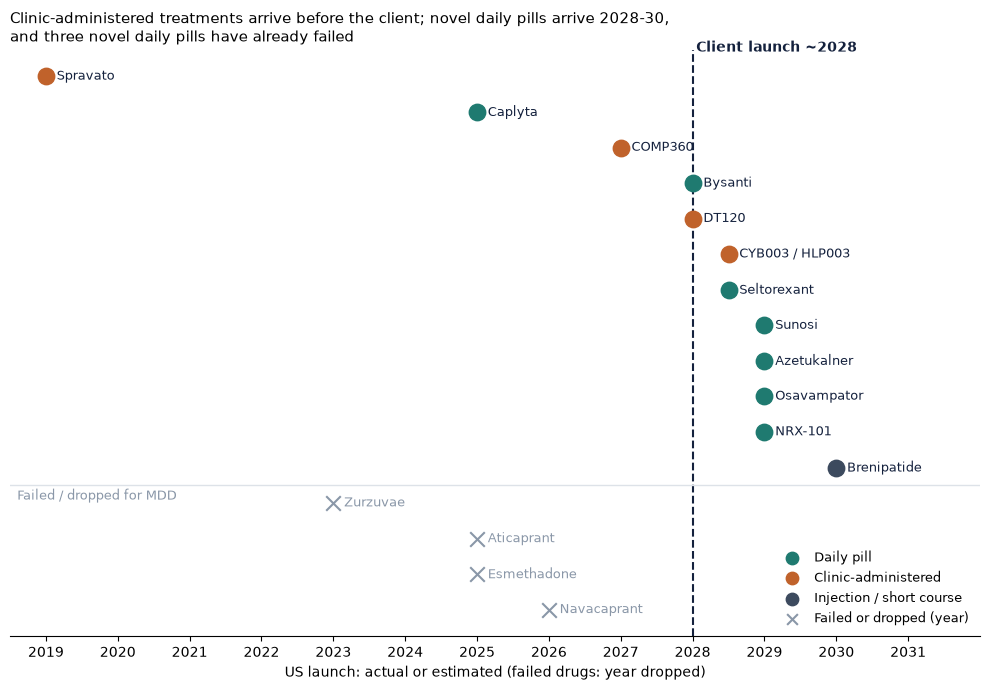

Not shown: Trintellix (already on market, new-population trial) and 7 China/Korea home-market candidates.


In [6]:
# Step 2d. Timeline: who reaches US patients before or after the client (~2028)?
COLORS = {"Daily pill": "#1F7A70", "Clinic-administered": "#C0622B", "Weekly injection": "#3C4A5E", "Short pill course (14 days)": "#3C4A5E"}
live = research[research.launch_year_est.notna()].sort_values("launch_year_est")
dead = research[research.out_year.notna()].sort_values("out_year")
rows = list(live.itertuples()) + list(dead.itertuples())

fig, ax = plt.subplots(figsize=(10, 7))
for y, r in enumerate(rows[::-1]):
    if pd.notna(r.launch_year_est):
        ax.scatter(r.launch_year_est, y, s=140, color=COLORS.get(r.treatment_model, "#8A97A8"), zorder=3)
        label_x = r.launch_year_est
    else:
        ax.scatter(r.out_year, y, s=110, marker="x", color="#8A97A8", zorder=3)
        label_x = r.out_year
    ax.text(label_x + 0.15, y, r.drug.split(" (")[0], va="center", fontsize=9,
            color="#14213D" if pd.notna(r.launch_year_est) else "#8A97A8")
ax.axvline(CLIENT_LAUNCH_YEAR, color="#14213D", ls="--", lw=1.5)
ax.text(CLIENT_LAUNCH_YEAR + 0.05, len(rows) - 0.3, "Client launch ~2028", fontsize=10, fontweight="bold", color="#14213D")
ax.axhline(len(dead) - 0.5, color="#DDE2E8", lw=1)
ax.text(2018.6, len(dead) - 0.9, "Failed / dropped for MDD", fontsize=9, color="#8A97A8")
for name, c in [("Daily pill", "#1F7A70"), ("Clinic-administered", "#C0622B"), ("Injection / short course", "#3C4A5E")]:
    ax.scatter([], [], color=c, s=80, label=name)
ax.scatter([], [], marker="x", color="#8A97A8", s=60, label="Failed or dropped (year)")
ax.legend(frameon=False, loc="lower right", fontsize=9)
ax.set_yticks([]); ax.set_xlim(2018.5, 2032); ax.set_xticks(range(2019, 2032))
ax.set_xlabel("US launch: actual or estimated (failed drugs: year dropped)")
ax.set_title("Clinic-administered treatments arrive before the client; novel daily pills arrive 2028-30,\n"
             "and three novel daily pills have already failed", loc="left", fontsize=11)
ax.spines[["top", "right", "left"]].set_visible(False)
plt.tight_layout(); plt.savefig(FIG + "ws2_timeline.png", dpi=200); plt.show()
print("Not shown: Trintellix (already on market, new-population trial) and 7 China/Korea home-market candidates.")

**2e. Caplyta in the launch region.** Caplyta (lumateperone, J&J) was approved as an add-on for depression in Nov 2025 and markets a low weight-gain profile, close to the client's tolerability pitch. An FDA approval is national, and insurers mostly cover a drug rather than a specific use, so where Caplyta already has prescribers and coverage it starts the depression race ahead.
- **Caplyta index** = Caplyta's share of all antipsychotic fills in a state ÷ its US share (1.0 = US average). Comparing within antipsychotics avoids mistaking a state with simply more Medicare patients for a Caplyta stronghold.
- Medicare 2024 data predates the depression approval (fills were for bipolar depression and schizophrenia): it shows existing prescribers and coverage, not depression use.
- Applied to the 13 candidate states from Workstream 1 (above the median on depression rate and branded add-on use), flagging the launch region (TN, KY, IN, OH, MI, WI) and where Caplyta is weaker.

In [7]:
# Step 2e. Caplyta (lumateperone) by state: how established is it where the client plans to launch?
geo = pd.read_csv(RAW + "cms_partd_geo_drug.csv", low_memory=False)
cap_mask = lambda df: df.Brnd_Name.str.contains("Caplyta", case=False, na=False)
ap_mask = lambda df: df.Antpsyct_Drug_Flag == "Y"          # CMS flag: every antipsychotic product (generic and brand)

nat = geo[geo.Prscrbr_Geo_Lvl == "National"]
us_share = nat[cap_mask(nat)].Tot_Clms.sum() / nat[ap_mask(nat)].Tot_Clms.sum() * 100
print(f"Caplyta, Medicare 2024 (before its depression approval): {nat[cap_mask(nat)].Tot_Clms.sum():,.0f} fills = "
      f"{us_share:.1f}% of all US antipsychotic fills")

# Caplyta index = Caplyta's share of antipsychotic fills in the state / its US share. 1.0 = US average; above 1 = stronger than average
st = geo[geo.Prscrbr_Geo_Lvl == "State"]
by_state = pd.DataFrame({"caplyta_fills": st[cap_mask(st)].groupby("Prscrbr_Geo_Desc").Tot_Clms.sum(),
                         "antipsychotic_fills": st[ap_mask(st)].groupby("Prscrbr_Geo_Desc").Tot_Clms.sum()}).dropna()
by_state["Caplyta % of antipsychotic fills"] = by_state.caplyta_fills / by_state.antipsychotic_fills * 100
by_state["Caplyta index (US = 1.0)"] = by_state["Caplyta % of antipsychotic fills"] / us_share

# Join to the Workstream 1 state measures (saved by notebook 02, Step 7)
ws1 = pd.read_csv(OUT + "ws1_state_launch_metrics.csv", index_col="stateabbr")
names = pd.read_csv(RAW + "cdc_places_county_2025.csv", usecols=["statedesc", "stateabbr"]).drop_duplicates()
names = pd.concat([names, pd.DataFrame({"statedesc": ["Kentucky", "Pennsylvania"], "stateabbr": ["KY", "PA"]})])
by_state = by_state.join(names.set_index("statedesc").stateabbr).set_index("stateabbr")
states = ws1.join(by_state[["Caplyta % of antipsychotic fills", "Caplyta index (US = 1.0)"]])

# Candidate states = the 13 above the median on both depression rate and branded add-on use (Workstream 1 chart, orange)
RANK_BY = "Branded add-on fills per 1,000 antidepressant fills"
cand = states[(states["Depression rate (%)"] > states["Depression rate (%)"].median()) & (states[RANK_BY] > states[RANK_BY].median())].copy()
REGION = ["TN", "KY", "IN", "OH", "MI", "WI"]      # launch region chosen in Workstream 1 (updated with Workstream 2)
cand["Plan"] = ["Launch region" if s in REGION else "-" for s in cand.index]
cand["Caplyta presence"] = pd.cut(cand["Caplyta index (US = 1.0)"], [0, 0.9, 1.1, 99], labels=["Weaker than US", "About average", "Stronger than US"])
cols = ["Plan", "Caplyta presence", "Caplyta index (US = 1.0)", "Depression rate (%)", RANK_BY, "Patients (M)", "Branded add-on spend ($M)"]
print(f"\nCandidate states ({len(cand)}), sorted from weakest to strongest Caplyta presence:")
display(cand.sort_values("Caplyta index (US = 1.0)")[cols].round(2))

Caplyta, Medicare 2024 (before its depression approval): 159,155 fills = 0.5% of all US antipsychotic fills

Candidate states (13), sorted from weakest to strongest Caplyta presence:


,Plan,Caplyta presence,Caplyta index (US = 1.0),Depression rate (%),"Branded add-on fills per 1,000 antidepressant fills",Patients (M),Branded add-on spend ($M)
stateabbr,,,,,,,
WI,Launch region,Weaker than US,0.74,23.21,16.89,1.08,44.38
MI,Launch region,About average,0.95,25.67,19.63,2.03,84.69
AR,-,About average,1.05,24.59,16.27,0.58,26.18
AL,-,Stronger than US,1.10,23.35,21.23,0.93,45.04
OH,Launch region,Stronger than US,1.19,25.41,19.62,2.34,111.76
LA,-,Stronger than US,1.30,26.59,24.89,0.93,48.85
NC,-,Stronger than US,1.31,24.18,16.62,2.05,81.27
MO,-,Stronger than US,1.34,24.34,22.68,1.17,70.86
KY,Launch region,Stronger than US,1.42,26.69,24.41,0.94,62.92


**2f. Focus competitors: head-to-head.** Of all the candidates, three compete most directly with the client's slot (an add-on pill for patients whose first antidepressant did not work well enough):
- **Caplyta**: closest today (already approved as an add-on, markets tolerability, strong in the launch region).
- **Bysanti**: arrives in the same year (~2028) as an add-on.
- **Osavampator**: closest future rival (novel and not an antipsychotic, like the client; ~2029).

Considered but not treated as direct competitors: **seltorexant** (only depressed patients with insomnia, a narrower group) and **azetukalner** (replaces the antidepressant rather than adding to it, a different slot). Vraylar and Rexulti remain today's market leaders (Workstream 1).

Three outputs: a head-to-head table, a positioning map (timing vs type of drug), and signposts (upcoming events that would change the picture, with the client's response).

,Client (fictional),Caplyta (lumateperone),Bysanti (milsaperidone),Osavampator (NBI-1065845)
Company,Mid-size biotech,Intra-Cellular / J&J,Vanda,Neurocrine
How it is used,Add-on to an antidepressant (second-line),Add-on (approved Nov 2025),Add-on (Phase 3 in depression),Add-on (Phase 3)
Type,"Novel, non-serotonin; NOT an antipsychotic",Antipsychotic,Antipsychotic,Novel (glutamate / AMPA); NOT an antipsychotic
Available for depression,~2028,On market (2025),~2028 (est.),~2029 (est.)
Evidence,Phase 3 data 2027,Two positive Phase 3s; approved,Depression Phase 3 ends ~end 2026,"Phase 3 started 2025, data ~2027"
Already known to doctors?,No (new drug),"Yes: bipolar, schizophrenia since 2019","Yes: bipolar, schizophrenia since Feb 2026",No (new drug)
Where the client WINS,-,Not an antipsychotic (no class warnings or stigma),Not an antipsychotic; similar size of company,~1-year head start
Where the client LOSES,-,"Already on market and covered; J&J sales force; strongest in TN, KY, IN (ind...",Arrives the same year; psychiatrists already know it,"Same story as the client (novel, not an antipsychotic); larger, specialist c..."


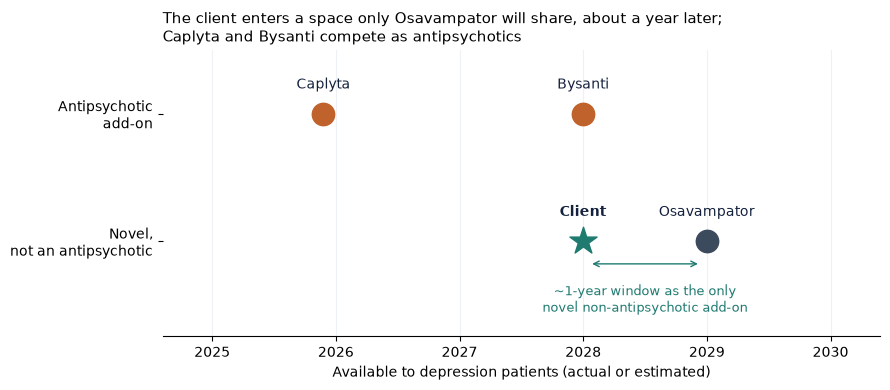

,When,Event,What it would mean,Client response
0,~end 2026,Bysanti depression Phase 3 results,Positive: a second antipsychotic add-on arrives with the client,Lead with 'not an antipsychotic'
1,2027,Client's own Phase 3 results,The go / no-go for the whole launch,-
2,~2027,Osavampator Phase 3 results,Positive: head-on rival ~2029. Negative: client stays the only novel non-ant...,If positive: launch all six states at once and lock in insurer contracts early
3,2027-28,CMS data on Caplyta use for depression (2025-26),Shows how fast Caplyta wins depression patients in the launch states,Re-check the launch region
4,2027-28,Medicare negotiated prices for Vraylar (2027) and Rexulti (2028),Lowers the price ceiling for add-ons,Set price against negotiated levels (Workstream 3)


In [8]:
# Step 2f. Head-to-head: the client vs its three focus competitors (from the research table in 2c and the Caplyta data in 2e)
h2h = pd.DataFrame({
    "Client (fictional)": ["Mid-size biotech", "Add-on to an antidepressant (second-line)", "Novel, non-serotonin; NOT an antipsychotic",
                           "~2028", "Phase 3 data 2027", "No (new drug)", "-", "-"],
    "Caplyta (lumateperone)": ["Intra-Cellular / J&J", "Add-on (approved Nov 2025)", "Antipsychotic",
                               "On market (2025)", "Two positive Phase 3s; approved", "Yes: bipolar, schizophrenia since 2019",
                               "Not an antipsychotic (no class warnings or stigma)",
                               "Already on market and covered; J&J sales force; strongest in TN, KY, IN (index 1.4-1.9)"],
    "Bysanti (milsaperidone)": ["Vanda", "Add-on (Phase 3 in depression)", "Antipsychotic",
                                "~2028 (est.)", "Depression Phase 3 ends ~end 2026", "Yes: bipolar, schizophrenia since Feb 2026",
                                "Not an antipsychotic; similar size of company",
                                "Arrives the same year; psychiatrists already know it"],
    "Osavampator (NBI-1065845)": ["Neurocrine", "Add-on (Phase 3)", "Novel (glutamate / AMPA); NOT an antipsychotic",
                                  "~2029 (est.)", "Phase 3 started 2025, data ~2027", "No (new drug)",
                                  "~1-year head start",
                                  "Same story as the client (novel, not an antipsychotic); larger, specialist company"],
}, index=["Company", "How it is used", "Type", "Available for depression", "Evidence", "Already known to doctors?",
          "Where the client WINS", "Where the client LOSES"])
display(h2h)

# Positioning map: when each reaches depression patients (x) vs what kind of drug it is (y)
pos = pd.DataFrame({"name": ["Caplyta", "Bysanti", "Client", "Osavampator"],
                    "year": [2025.9, 2028.0, 2028.0, 2029.0],
                    "row":  [1, 1, 0, 0]})        # 1 = antipsychotic add-on, 0 = novel non-antipsychotic add-on
fig, ax = plt.subplots(figsize=(9, 4))
for _, r in pos.iterrows():
    client = r["name"] == "Client"
    ax.scatter(r.year, r.row, s=420 if client else 260, marker="*" if client else "o",
               color="#1F7A70" if client else ("#C0622B" if r.row == 1 else "#3C4A5E"), zorder=3)
    ax.annotate(r["name"], (r.year, r.row), xytext=(0, 18), textcoords="offset points", ha="center",
                fontsize=10, fontweight="bold" if client else "normal", color="#14213D")
ax.annotate("", xy=(2028.95, -0.18), xytext=(2028.05, -0.18), arrowprops=dict(arrowstyle="<->", color="#1F7A70"))
ax.text(2028.5, -0.33, "~1-year window as the only\nnovel non-antipsychotic add-on", ha="center", va="top", fontsize=9, color="#1F7A70")
ax.set_yticks([0, 1]); ax.set_yticklabels(["Novel,\nnot an antipsychotic", "Antipsychotic\nadd-on"])
ax.set_xticks(range(2025, 2031)); ax.set_xlim(2024.6, 2030.4); ax.set_ylim(-0.75, 1.5)
ax.set_xlabel("Available to depression patients (actual or estimated)")
ax.set_title("The client enters a space only Osavampator will share, about a year later;\n"
             "Caplyta and Bysanti compete as antipsychotics", loc="left", fontsize=11)
ax.spines[["top", "right", "left"]].set_visible(False); ax.grid(axis="x", color="#EEF1F4")
plt.tight_layout(); plt.savefig(FIG + "ws2_positioning.png", dpi=200); plt.show()

# Signposts: upcoming events that would change the picture, and how the client should respond
signposts = pd.DataFrame([
    ["~end 2026", "Bysanti depression Phase 3 results", "Positive: a second antipsychotic add-on arrives with the client", "Lead with 'not an antipsychotic'"],
    ["2027", "Client's own Phase 3 results", "The go / no-go for the whole launch", "-"],
    ["~2027", "Osavampator Phase 3 results", "Positive: head-on rival ~2029. Negative: client stays the only novel non-antipsychotic add-on longer",
     "If positive: launch all six states at once and lock in insurer contracts early"],
    ["2027-28", "CMS data on Caplyta use for depression (2025-26)", "Shows how fast Caplyta wins depression patients in the launch states",
     "Re-check the launch region"],
    ["2027-28", "Medicare negotiated prices for Vraylar (2027) and Rexulti (2028)", "Lowers the price ceiling for add-ons", "Set price against negotiated levels (Workstream 3)"],
], columns=["When", "Event", "What it would mean", "Client response"])
display(signposts)

## Step 3: Non-drug alternatives
When the first antidepressant does not work well enough, the doctor's options are not only drugs: switch pills, add a drug (the client's slot), or use a clinic treatment, an app or therapy. The client's share depends on this whole menu, so the main non-drug options are profiled here.
- **3a.** Trial activity for each alternative, from the same ClinicalTrials.gov download (keyword match on intervention names and titles: an indicator of research momentum, not of market size).
- **3b.** Profile of each alternative: who it is for, how it is given, cost, insurance and evidence (desk research, `data/processed/ws2_nondrug_research.csv`).

In [9]:
# Step 3a. How much trial activity is there for each non-drug alternative? (all 7,393 depression trials, any sponsor)
text = (trials.interventions.fillna("") + " " + trials.title.fillna("")).str.lower()
ALTERNATIVES = {
    "TMS / brain stimulation": r"\btms\b|transcranial magnetic|theta burst|\bitbs\b|\brtms\b|saint",
    "Digital / app": r"\bapp\b|smartphone|digital|internet-based|online|mobile|web-based|ehealth|mhealth",
    "Ketamine / esketamine": r"ketamine",
    "Psilocybin / psychedelics": r"psilocybin|lsd|lysergide|dmt|mdma|psychedelic",
    "Psychotherapy (CBT etc.)": r"cognitive behavio|\bcbt\b|psychotherapy|behavioral activation|interpersonal therapy|mindfulness",
}
counts = pd.DataFrame({name: text.str.contains(pat, regex=True) for name, pat in ALTERNATIVES.items()})
trials["period"] = pd.cut(trials.start_year, [2014, 2019, 2024, 2030], labels=["2015-19", "2020-24", "2025+"])
summary3 = pd.DataFrame({
    "Trials (2015+)": counts.sum(),
    "Started 2015-19": counts[trials.period == "2015-19"].sum(),
    "Started 2020-24": counts[trials.period == "2020-24"].sum(),
    "Company-sponsored": counts[trials.sponsor_class == "INDUSTRY"].sum(),
    "Still running": counts[trials.status.isin(ACTIVE)].sum(),
})
summary3["Growth 2020-24 vs 2015-19 (%)"] = (summary3["Started 2020-24"] / summary3["Started 2015-19"] - 1) * 100
print("Keyword match on intervention names and titles; a trial can match several alternatives.")
display(summary3.sort_values("Trials (2015+)", ascending=False).round(0))

# Step 3b. Profiles of the four alternatives (desk research, Oct 2026; sources in the file)
nondrug = pd.read_csv(OUT + "ws2_nondrug_research.csv")
display(nondrug.drop(columns="source"))

Keyword match on intervention names and titles; a trial can match several alternatives.


,Trials (2015+),Started 2015-19,Started 2020-24,Company-sponsored,Still running,Growth 2020-24 vs 2015-19 (%)
Psychotherapy (CBT etc.),1089,347,535,22,312,54.0
Digital / app,852,179,478,44,256,167.0
TMS / brain stimulation,437,116,206,13,188,78.0
Ketamine / esketamine,279,105,119,38,80,13.0
Psilocybin / psychedelics,117,9,64,13,66,611.0


,alternative,what_it_is,patients,how_given,typical_cost,insurance,evidence,threat_to_client
0,TMS (incl. accelerated SAINT),Magnetic pulses to mood-related brain areas; non-invasive,After 2+ failed antidepressants (insurer rule); overlaps with client's secon...,"Clinic: 36 sessions over 6-9 weeks (SAINT: 50 sessions in 5 days, FDA-cleare...","$7,200-15,000 per course cash; SAINT $30,000-36,000","Usually covered after 2-4 failed antidepressants, with pre-approval; $500-3,...","Established, FDA-cleared","Medium: competes for patients failing pills, but needs daily clinic visits"
1,Prescription digital app (Rejoyn),Smartphone program: cognitive-emotional training + CBT lessons,Adults with MDD on an antidepressant who responded only partly: the client's...,"Self-use at home: 18 sessions over 6 weeks, alongside an antidepressant",Not disclosed,Uncertain,"FDA-cleared Apr 2024 (Otsuka, Click Therapeutics), but trial did not beat a ...","Low: weak evidence, uncertain coverage; more a complement than a substitute"
2,Ketamine infusion clinics,Off-label IV ketamine (the drug is FDA-approved only as an anaesthetic),"Treatment-resistant patients, next to Spravato","Clinic: 4-6 infusions over ~2 weeks, then boosters","$300-1,500 per infusion; $1,200-9,000 per course",Rarely covered (off-label); mostly cash,"Fast effect; off-label, limited long-term data","Low-medium: severe, cash-paying patients; one step beyond the client"
3,Psychotherapy (e.g. CBT),Talk therapy with a trained therapist,All severities; usually combined with medication,"Weekly sessions, in person or online",Varies; covered by most plans,Widely covered (mental health parity),Adding therapy to antidepressants improves outcomes vs pills alone (meta-ana...,"Low as a substitute: mostly used alongside pills, so a complement"


**Other options, noted but not profiled** (lower relevance to the client's second-line patients):
- **ECT** (electroconvulsive therapy) and **implanted stimulation** (vagus nerve, deep brain): severe, last-resort cases, a step beyond the client's patients.
- **Legal psilocybin services** (Oregon since 2023, Colorado since 2025, New Mexico medical program from ~end 2026): growing (Oregon: ~3,500 clients in the first year, 5,935 in 2025) but tiny, cash-only (~$1,000-3,000), centers closing (31 to 23), none in the launch states. Useful mainly as a demand signal for psychedelic drugs.
- **Wellness apps, exercise, light therapy, supplements, retreats**: mostly mild depression, not second-line; no reliable data.

**Access contrast:** the client's pill is reimbursed by insurance, including Medicaid and Medicare (antidepressants and antipsychotics are protected classes in Part D), while ketamine clinics and psilocybin services are mostly cash-pay. Depression is more common among lower-income adults, so insurance coverage is a real advantage; winning good formulary placement is a Workstream 3 question.

## Step 4: Lessons from recent launches
How comparable drugs reached patients (company results and trade press, Oct 2026; details and sources in `docs/deck_notes.md`):

| Launch | What happened | Lesson for the client |
|---|---|---|
| **Auvelity** (Axsome, mid-size, Oct 2022) | 162 reps at launch, 260 after a year, 630 by 2026. Commercial insurers blocked it ~6 months; commercial coverage ~40% to ~48% in year 1, while Medicare/Medicaid were ~100%. Sales $5M (launch quarter) to $49M (Q4 2023); $130M in year 1, >$600M a year by 2026. Growth led by psychiatry practices incl. nurse practitioners and physician assistants; savings card, samples, prior-authorisation help, telehealth. Management: sales force = best return on investment, advertising later. | Expect a commercial-coverage lag; a daily drug compounds as patients refill; the prescriber network drives growth |
| **Caplyta** (Intra-Cellular, now J&J) | New uses launched with coverage already in place (>98% government, >80% commercial). J&J paid $14.6B; targets ~$5B a year. | The incumbent's advantage is commercial coverage on day one |
| **Exxua** (gepirone) | Approved Sep 2023, reached pharmacies only ~late 2025, after licensing to a company with a sales force | Approval is not launch: be commercially ready before approval |
| **Zurzuvae** (Sage/Biogen) | Rejected for depression; approved for postpartum only; main prescribers (OB-GYNs) differed from enthusiastic psychiatrists | Target the doctors who actually treat the patients |
| **Vraylar** (AbbVie) | Heavy TV advertising to patients ($13.1M in one month) | Advertising is a lever, but costly; for a mid-size company the sales force comes first |

Benchmark: about two-thirds of launches miss their forecasts; launches reaching 30% of priority prescribers, 50% repeat prescribing and 30% with 3+ patients by month 6 were ~9x more likely to succeed (ZS, 18 launches).

## Step 5: Key takeaways
1. **Pipeline:** 7,393 depression trials narrow to 118 late-stage company drug trials and 72 candidates; of 24 Phase 3 candidates, about 12 are realistic new US competitors (4 failed, 7 China/Korea home-market only, Trintellix already on market). Novel daily pills often fail: 3 have failed in Phase 3.
2. **Focus competitors:** **Caplyta** (closest today: approved as an add-on Nov 2025, markets tolerability, J&J, strongest in TN, KY, IN), **Bysanti** (add-on, ~2028, same year as the client) and **osavampator** (closest future rival, ~2029: novel and not an antipsychotic, like the client; backed by Neurocrine's existing psychiatry sales force). Caplyta and Bysanti are antipsychotics; the client is not.
3. **Clinic-based treatments** (Spravato, COMP360 ~2027, DT120 ~2028) arrive before or with the client but serve more severe patients with a supervised, clinic-based model; non-drug options (TMS, ketamine clinics, apps, therapy) are mostly cash-pay, burdensome or complements to pills.
4. **Access:** Medicare and Medicaid must cover antidepressants and antipsychotics, but commercial insurers block new drugs for ~6 months and cover only ~half in year 1; competitors' Medicare copays are already $11-41 per fill, so the battle is coverage and tier placement, not copay.
5. **Hypothesis verdict:** "the client's novel mechanism will stand out" is **partly confirmed**: novel at launch, but for only about a year, and Caplyta narrows the tolerability edge.

**So what for the client:** the client enters 2028 as the only add-on that is not an antipsychotic, but only for about a year. Caplyta (J&J) is already strong in the launch region and Bysanti arrives the same year, both as antipsychotics; osavampator, backed by Neurocrine's psychiatry sales force, would match the client's story around 2029. So the client must:
1. **Be commercially ready before approval** (sales force, supply, patient-support hub, early talks with insurers): Exxua lost about 2 years without this.
2. **Build the right prescriber network early**, including psychiatry practices with nurse practitioners and physician assistants, which drove Auvelity's growth; by month 6, aim for broad first prescribing and repeat prescribing.
3. **Expect commercial insurers to lag** (~6-month block, then ~50% coverage after a year): start with Medicare and Medicaid patients and bridge commercial patients until coverage arrives.
4. **Lead with "the add-on benefit without adding an antipsychotic"** against Caplyta and Bysanti.

*Open items: options to shorten FDA review (priority review, vouchers) to widen the window; national-by-prescriber vs six-state targeting (Workstream 4); price, rebates and coverage terms (Workstream 3).*